# Ringdown mode corner plots

This notebook loads a two-mode ringdown result and produces separate corner plots for each mode, using the same ArviZ-style pair plotting approach as the TD inference results notebook.

In [8]:
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

try:
    from ringdown.result import Result
except Exception:
    Result = None


In [9]:
repo = Path.cwd().resolve()
while not (repo / 'README.md').exists():
    repo = repo.parent

ringdown_dir = repo.parent / 'datadir' / 'ringdown_output'
RESULT_PATH = ringdown_dir / 'total_fit_result3.nc'
OUTPUT_DIR = repo / 'results' / 'ringdown' / 'plots' / 'mode_corner_plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLOT_VAR_CANDIDATES = ['a', 'f', 'g', 'ellip', 'phi', 'theta']
MODE_NAME_MAP = {
    '1,-2,2,2,0': '220',
    '1,-2,2,2,1': '221',
}

print(f'Using result file: {RESULT_PATH}')
print(f'Output directory: {OUTPUT_DIR}')


Using result file: /home/selmavangstein/mastersproject/gw_boson_star_testing_gr/ringdown_results/total_fit_result3.nc
Output directory: /home/selmavangstein/mastersproject/gw_boson_star_testing_gr/fitresults_plots/mode_corner_plots


In [10]:
def load_result(path):
    if Result is not None:
        return Result.from_netcdf(path)
    return az.from_netcdf(path)


def decode_mode_name(raw_mode):
    if isinstance(raw_mode, bytes):
        raw_mode = raw_mode.decode()
    raw_mode = str(raw_mode)
    return MODE_NAME_MAP.get(raw_mode, raw_mode)


def build_mode_idata(posterior, mode_index, plot_vars):
    mode_posterior = {}
    for var_name in plot_vars:
        if var_name not in posterior.data_vars:
            continue
        data_array = posterior[var_name]
        if 'mode' not in data_array.dims:
            continue
        mode_posterior[var_name] = data_array.isel(mode=mode_index).values
    if not mode_posterior:
        raise ValueError(f'No mode-dependent posterior variables found for mode index {mode_index}')
    return az.from_dict(posterior=mode_posterior)


def flatten_mode_samples(posterior, mode_index, plot_vars):
    flat = {}
    for var_name in plot_vars:
        if var_name not in posterior.data_vars:
            continue
        data_array = posterior[var_name]
        if 'mode' not in data_array.dims:
            continue
        flat[var_name] = np.asarray(data_array.isel(mode=mode_index)).reshape(-1)
    return flat


In [11]:
idata = load_result(RESULT_PATH)
posterior = idata.posterior
mode_values = list(posterior.coords['mode'].values)
mode_labels = [decode_mode_name(mode) for mode in mode_values]
plot_vars = [name for name in PLOT_VAR_CANDIDATES if name in posterior.data_vars]

print('Available mode labels:', mode_labels)
print('Plotting variables:', plot_vars)
print('Posterior dimensions:', dict(posterior.dims))


Available mode labels: ['220', '221']
Plotting variables: ['a', 'f', 'g', 'ellip', 'phi', 'theta']
Posterior dimensions: {'chain': 4, 'draw': 2000, 'mode': 2, 'ifo': 2, 'time_index': 819}


/tmp/ipykernel_148479/2165844448.py:9: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('Posterior dimensions:', dict(posterior.dims))


In [12]:
summary_rows = []
for mode_index, mode_label in enumerate(mode_labels):
    flat_samples = flatten_mode_samples(posterior, mode_index, plot_vars)
    mode_summary = {
        'mode': mode_label,
        'nsamples': len(next(iter(flat_samples.values()))) if flat_samples else 0,
    }
    for var_name, values in flat_samples.items():
        mode_summary[f'{var_name}_median'] = float(np.median(values))
        mode_summary[f'{var_name}_p05'] = float(np.percentile(values, 5))
        mode_summary[f'{var_name}_p95'] = float(np.percentile(values, 95))
    summary_rows.append(mode_summary)

summary_rows


[{'mode': '220',
  'nsamples': 8000,
  'a_median': 5.127373134860491e-21,
  'a_p05': 2.9808961927834625e-21,
  'a_p95': 7.918947355203921e-21,
  'f_median': 250.2401123046875,
  'f_p05': 237.9642333984375,
  'f_p95': 263.6839294433594,
  'g_median': 251.20120239257812,
  'g_p05': 188.38673400878906,
  'g_p95': 316.5162353515625,
  'ellip_median': -0.27550995349884033,
  'ellip_p05': -0.48513340950012207,
  'ellip_p95': -0.1511009782552719,
  'phi_median': -1.1532516479492188,
  'phi_p05': -1.5722838640213013,
  'phi_p95': -0.39393970370292664,
  'theta_median': 1.293256163597107,
  'theta_p05': 1.0399346351623535,
  'theta_p95': 1.4656912088394165},
 {'mode': '221',
  'nsamples': 8000,
  'a_median': 1.172264571745917e-21,
  'a_p05': 1.1899004976043318e-22,
  'a_p95': 5.1946829377230765e-21,
  'f_median': 243.81759643554688,
  'f_p05': 230.15428161621094,
  'f_p95': 258.35089111328125,
  'g_median': 760.159423828125,
  'g_p05': 568.0103759765625,
  'g_p95': 965.5016479492188,
  'ellip_m

/home/selmavangstein/miniconda3/envs/ringdown/lib/python3.11/site-packages/arviz/plots/backends/matplotlib/kdeplot.py:166: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contour(x_x, y_y, density, **contour_kwargs)


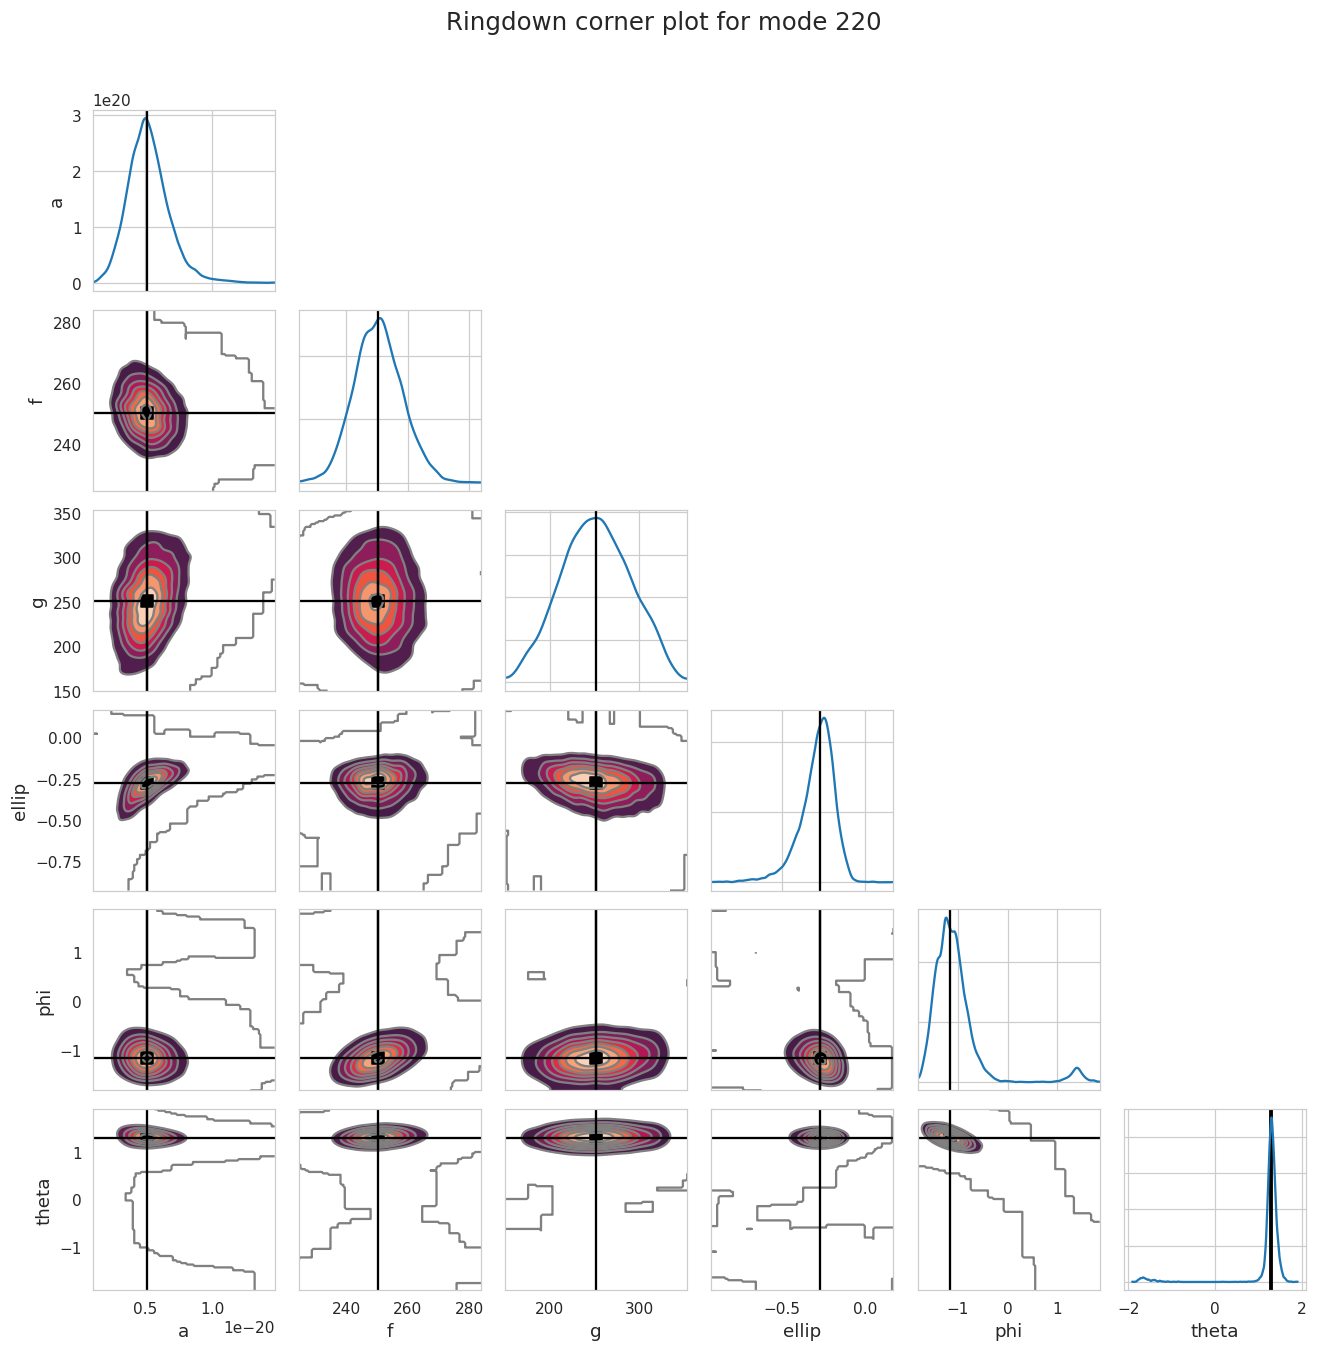

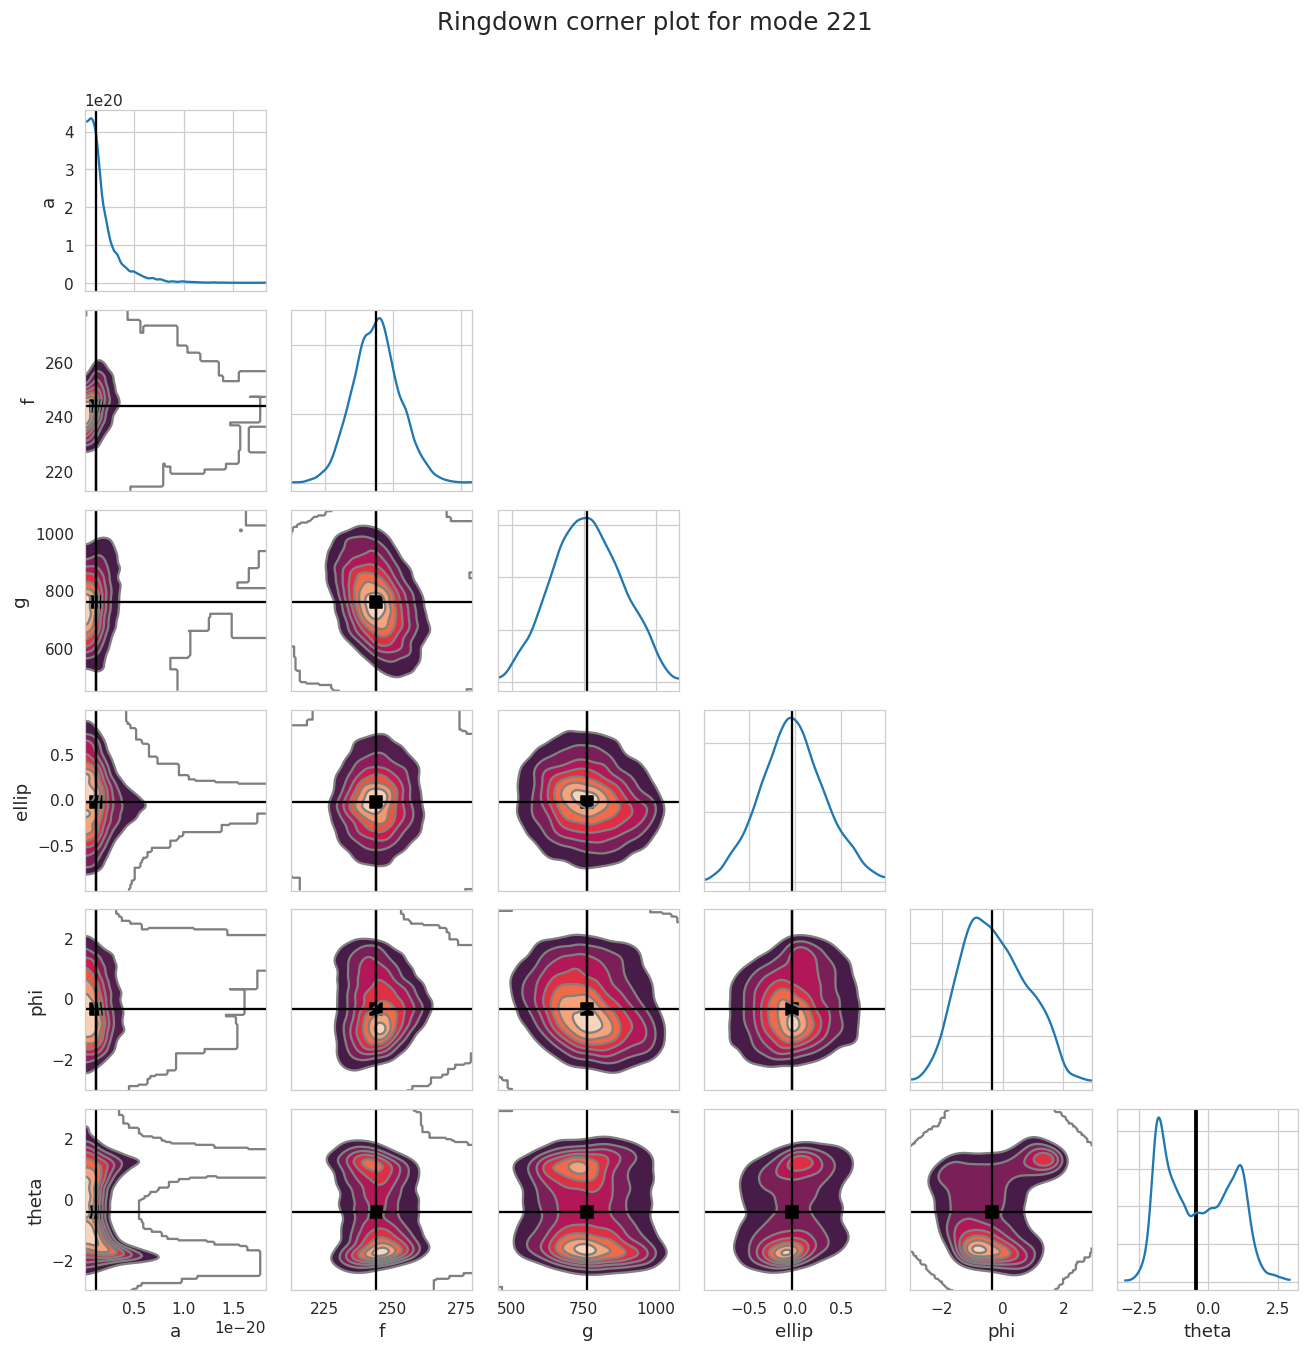

Saved files:
  - /home/selmavangstein/mastersproject/gw_boson_star_testing_gr/fitresults_plots/mode_corner_plots/corner_plot_mode_220.png
  - /home/selmavangstein/mastersproject/gw_boson_star_testing_gr/fitresults_plots/mode_corner_plots/corner_plot_mode_221.png


In [13]:
saved_paths = []
for mode_index, mode_label in enumerate(mode_labels):
    mode_idata = build_mode_idata(posterior, mode_index, plot_vars)

    plt.close('all')
    az.plot_pair(
        mode_idata,
        var_names=plot_vars,
        kind='kde',
        marginals=True,
        point_estimate='median',
        figsize=(12, 12),
        kde_kwargs={'contour_kwargs': {'linewidths': 1.5}},
    )
    plt.suptitle(f'Ringdown corner plot for mode {mode_label}', y=1.02, fontsize=16)
    plt.tight_layout()

    save_path = OUTPUT_DIR / f'corner_plot_mode_{mode_label}.png'
    plt.savefig(save_path, dpi=180, bbox_inches='tight')
    saved_paths.append(save_path)
    plt.show()

print('Saved files:')
for path in saved_paths:
    print(f'  - {path}')
